# Custom Data Preprocessing for JPF-WCA Dataset

This script demonstrates how we perform our own data transformations for our own custom dataset. We implement `make_map_fn` functions to extract answers and format each example according to the required structure. The steps include:

- Loading the dataset that we created manually.
- Processing each example using a custom mapping function:
    - Constructing a data item with the fields: `data_source`, `prompt`, `ability`, `reward_model`, and `extra_info`.
- Saving the processed dataset in parquet format locally.
- Copying the local data to HDFS.

You can modify these functions to suit your own dataset or task requirements.


In [1]:
import pandas as pd

df = pd.read_parquet("../data/eval-base.parquet")


In [2]:
df

,problem,problem_uuid,example_indices,examples,question,answer_index,answer_constants,answer_solution,variable_mapping
0,SimpleAscendingLast,cf09e751-1dee-4a9a-851a-7f2cb09ac34d,"[1, 2, 3]","[{'index': 1, 'solution': None}, {'index': 2, ...",A conversation between User and Assistant. The...,26,(declare-const n_8 Int)\n(declare-const q_1 In...,(assert (and (and (and (and (and (and (and (an...,"{'get0': None, 'get1': None, 'in0': 'e_26', 'i..."
1,SimpleAscendingLast,d032bbc6-cdd2-4dd8-b3c0-7ea96888df2c,"[1, 2, 4]","[{'index': 1, 'solution': None}, {'index': 2, ...",A conversation between User and Assistant. The...,14,(declare-const param_14 Int)\n(declare-const b...,(assert (and (and (and (and (and (and (and (an...,"{'get0': None, 'get1': None, 'in0': 'param_14'..."
2,SimpleAscendingLast,15b33d1b-48dc-4f86-9b3b-87ef1772c1d7,"[1, 2, 5]","[{'index': 1, 'solution': None}, {'index': 2, ...",A conversation between User and Assistant. The...,11,(declare-const i_4 Int)\n(declare-const global...,(assert (and (and (and (and (and (and (and (an...,"{'get0': None, 'get1': None, 'in0': 'l_11', 'i..."
3,SimpleAscendingLast,ff9d27b1-0bdd-422f-bb28-9341d1ba3e1a,"[1, 2, 6]","[{'index': 1, 'solution': None}, {'index': 2, ...",A conversation between User and Assistant. The...,21,(declare-const x_21 Int)\n(declare-const r_18 ...,(assert (and (and (and (and (and (and (and (an...,"{'get0': None, 'get1': None, 'in0': 'x_21', 'i..."
4,SimpleAscendingLast,8d3c634a-a06e-4e8a-978b-5411197499a4,"[1, 2, 7]","[{'index': 1, 'solution': None}, {'index': 2, ...",A conversation between User and Assistant. The...,20,(declare-const w_20 Int)\n(declare-const r_17 ...,(assert (and (and (and (and (and (and (and (an...,"{'get0': None, 'get1': None, 'in0': 'w_20', 'i..."
...,...,...,...,...,...,...,...,...,...
21291,ComplexHalfEqual,7f57df37-c51e-425c-ab2c-3e4c13a2ba5b,"[1, 2, 3, 5, 6, 7, 8, 9, 10]","[{'index': 1, 'solution': None}, {'index': 2, ...",A conversation between User and Assistant. The...,22,(declare-const e_22 Int)\n(declare-const tmp_1...,(assert (and (and (and (and (and (and (and (an...,"{'get0': None, 'get1': None, 'in0': 'e_22', 'i..."
21292,ComplexHalfEqual,7557fd4a-eb00-49e3-be67-804c6e9d5b08,"[1, 2, 4, 5, 6, 7, 8, 9, 10]","[{'index': 1, 'solution': None}, {'index': 2, ...",A conversation between User and Assistant. The...,18,(declare-const v_18 Int)\n(declare-const f_4 I...,(assert (and (and (and (and (and (and (and (an...,"{'get0': None, 'get1': None, 'in0': 'v_18', 'i..."
21293,ComplexHalfEqual,bd7dab8e-392a-4331-9892-507bda759b71,"[1, 3, 4, 5, 6, 7, 8, 9, 10]","[{'index': 1, 'solution': None}, {'index': 3, ...",A conversation between User and Assistant. The...,13,(declare-const n_13 Int)\n(declare-const out_3...,(assert (and (and (and (and (and (and (and (an...,"{'get0': None, 'get1': None, 'in0': 'n_13', 'i..."
21294,ComplexHalfEqual,01324898-4615-462c-9344-f90180d83e5b,"[2, 3, 4, 5, 6, 7, 8, 9, 10]","[{'index': 2, 'solution': '(assert ( = param...",A conversation between User and Assistant. The...,12,(declare-const u_4 Int)\n(declare-const t_7 In...,(assert (and (and (and (and (and (and (and (an...,"{'get0': None, 'get1': None, 'in0': 'param_12'..."


In [3]:
df.loc[0]

problem                                           SimpleAscendingLast
problem_uuid                     cf09e751-1dee-4a9a-851a-7f2cb09ac34d
example_indices                                             [1, 2, 3]
examples            [{'index': 1, 'solution': None}, {'index': 2, ...
question            A conversation between User and Assistant. The...
answer_index                                                       26
answer_constants    (declare-const n_8 Int)\n(declare-const q_1 In...
answer_solution     (assert (and (and (and (and (and (and (and (an...
variable_mapping    {'get0': None, 'get1': None, 'in0': 'e_26', 'i...
Name: 0, dtype: object

In [4]:
# Check if there are any duplicates in problem_uuid
df["problem_uuid"].duplicated().any()

False

In [5]:
# Check if any row the examples array's solution is all None
df["examples"].apply(lambda x: all([e["solution"] is None for e in x])).any()

True

In [6]:
# Show all the rows that have examples with all None solutions
df[df["examples"].apply(lambda x: all([e["solution"] is None for e in x]))]

,problem,problem_uuid,example_indices,examples,question,answer_index,answer_constants,answer_solution,variable_mapping
13552,SimpleEveryThird,15becc49-e4fe-4f57-a0d9-7ee6a414d737,"[1, 2, 3]","[{'index': 1, 'solution': None}, {'index': 2, ...",A conversation between User and Assistant. The...,22,(declare-const e_2 Int)\n(declare-const p_4 In...,(assert (and (and (and (and (and (and ( = p_...,"{'get0': None, 'get1': None, 'in0': None, 'in0..."


In [7]:
df.drop(df[df["examples"].apply(lambda x: all([e["solution"] is None for e in x]))].index, inplace=True)

In [8]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B")

# Remove all the question that are greater than 1.8k tokens
print("Before filtering", len(df))

df.drop(df[df["question"].apply(lambda x: len(tokenizer(x)["input_ids"])) > 1800].index, inplace=True)

print("After filtering", len(df))

/Users/dankoh/ConStruct/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Before filtering 21295
After filtering 19018


In [9]:
def make_map_fn(split):
    def process_fn(row):
        data = {
            "data_source": "dannkoh/ConStruct",
            "prompt": [{"role": "user", "content": row["question"]}],
            "ability": "generalisation",
            "reward_model": {"style": "rule", "ground_truth": row["answer_solution"]},
            "extra_info": {
                "answer_constants": row["answer_constants"],
                "variable_mapping": row["variable_mapping"],
                "answer_index": row["answer_index"],
                "example_indices": row["example_indices"],
                "problem_uuid": row["problem_uuid"],
            },
        }
        return data

    return process_fn

In [10]:
# Split the data into 2 parts: one for training and one for testing (75% training, 25% testing)
train = df.sample(frac=0.75, random_state=0)
test = df.drop(train.index)

train_dataset = pd.DataFrame(train.apply(make_map_fn("train"), axis=1).tolist())
test_dataset = pd.DataFrame(test.apply(make_map_fn("test"), axis=1).tolist())

In [11]:
train_dataset.to_parquet("train.parquet")
test_dataset.to_parquet("test.parquet")

In [12]:
# max, min, mean prompt token length of qwen tokenizer

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B")

print("Max prompt token length:", df["question"].apply(tokenizer.tokenize).apply(len).max())
print("Min prompt token length:", df["question"].apply(tokenizer.tokenize).apply(len).min())
print("Mean prompt token length:", df["question"].apply(tokenizer.tokenize).apply(len).mean())

Max prompt token length: 1800
Min prompt token length: 318
Mean prompt token length: 776.5412766852455


count    19018.000000
mean       776.541277
std        326.649703
min        318.000000
25%        555.000000
50%        703.000000
75%        904.000000
max       1800.000000
Name: token_length, dtype: float64

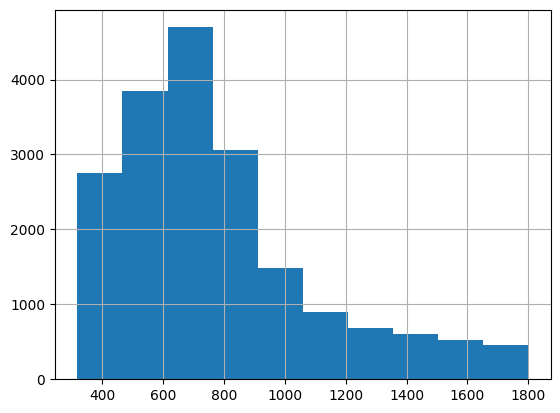

In [13]:
temp = df.copy()
temp["token_length"] = df["question"].apply(tokenizer.tokenize).apply(len)

temp["token_length"].hist()

temp["token_length"].describe()

In [14]:
# get tokenized prompt length distribution

distribution = df["question"].apply(tokenizer.tokenize).apply(len).value_counts().sort_index()

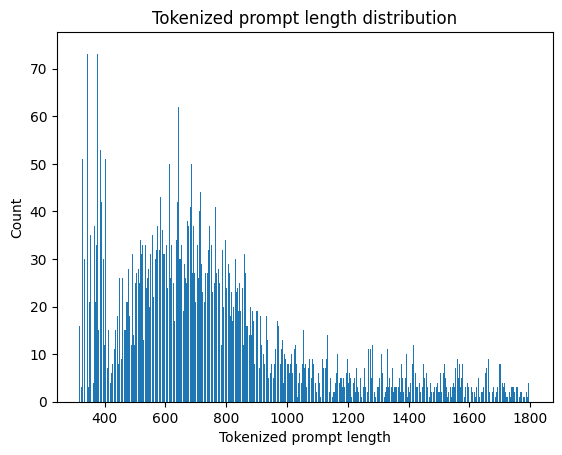

1281.0

In [15]:
# Plot distribution and take a subset of the data to use.
import matplotlib.pyplot as plt

plt.bar(distribution.index, distribution.values)
plt.xlabel("Tokenized prompt length")
plt.ylabel("Count")
plt.title("Tokenized prompt length distribution")
plt.show()

# Take the 90th percentile of the data
df["question"].apply(tokenizer.tokenize).apply(len).quantile(0.9)